In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [61]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f7
function_folder = os.path.join(base_dir, "function_7")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f7 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 7: shape = {df_f7.shape}, columns = {df_f7.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']


In [62]:
week1_results = {"f7": ([0.799542, 0.949047, 0.887638, 0.265662, 0.631518, 0.349925], 0.026543407526137847)}

In [63]:
week2_results = {"f7": ([0.008500, 0.278800, 0.231600, 0.099300, 0.323000, 0.980800], 0.7653612109103147)}

In [64]:
week3_results = {"f7": ([0.000000, 0.189754, 0.123991, 0.253411, 0.406355, 0.251864], 0.4981320924641522)}

In [65]:
week4_results = {"f7": ([0.097366, 0.334928, 0.369818, 0.382418, 0.464971, 0.750762], 1.5985145628892428)}

In [66]:
week5_results = {"f7": ([0.053955, 0.757891, 0.608290, 0.473788, 0.364363, 0.971498], 0.32752252967109274)}

In [67]:
week6_results = {"f7": ([0.069772, 0.319669, 0.577421, 0.210909, 0.386068, 0.707262], 2.448290856114691)}

In [68]:
week7_results = {"f7": ([0.064462, 0.412641, 0.669514, 0.193009, 0.502173, 0.667338], 1.3516399930526517)}

In [69]:
week8_results = {"f7": ([0.186891, 0.934228, 0.522974, 0.187825, 0.066947, 0.841778], 0.13054782987236474)}

In [70]:
week9_results = {"f7": ([0.019978, 0.998379, 0.127323, 0.788041, 0.383133, 0.520111], 0.01764809003897648)}

In [71]:
week10_results = {"f7": ([0.125310, 0.292720, 0.563314, 0.153089, 0.354283, 0.706302], 2.55796551675835)}

In [72]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f7

for week, results in weekly_results.items():
    
    if "f7" not in results:
        continue
    
    inputs, output = results["f7"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f7
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "X4", "X5", "X6", "y1"]
    )
    
    # append to df_f7
    df_f7 = pd.concat([df_f7, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f7 = df_f7.drop_duplicates(ignore_index=True)

print("updated f7 shape:", df_f7.shape)


updated f7 shape: (40, 7)


In [73]:
print(df_f7)

          X1        X2        X3        X4        X5        X6        y1
0   0.272624  0.324495  0.897109  0.832951  0.154063  0.795864  0.604433
1   0.543003  0.924694  0.341567  0.646486  0.718440  0.343133  0.562753
2   0.090832  0.661529  0.065931  0.258577  0.963453  0.640265  0.007503
3   0.118867  0.615055  0.905816  0.855300  0.413631  0.585236  0.061424
4   0.630218  0.838097  0.680013  0.731895  0.526737  0.348429  0.273047
5   0.764919  0.255883  0.609084  0.218079  0.322943  0.095794  0.083747
6   0.057896  0.491672  0.247422  0.218118  0.420428  0.730970  1.364968
7   0.195252  0.079227  0.554580  0.170567  0.014944  0.107032  0.092645
8   0.642303  0.836875  0.021793  0.101488  0.683071  0.692416  0.017870
9   0.789943  0.195545  0.575623  0.073659  0.259049  0.051100  0.033565
10  0.528497  0.457424  0.360096  0.362046  0.816891  0.637476  0.073516
11  0.722615  0.011813  0.063646  0.165173  0.079244  0.359952  0.206310
12  0.075665  0.334502  0.132733  0.608312  0.91838

In [74]:
display(df_f7.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,40.0,0.418783,0.328352,0.000000,0.095733,0.368718,0.735944,0.942451
X2,40.0,0.433553,0.275487,0.011813,0.243025,0.387701,0.617395,0.998379
X3,40.0,0.409254,0.298145,0.003635,0.126490,0.364957,0.624192,0.924571
X4,40.0,0.459801,0.300940,0.073659,0.206434,0.372232,0.764229,0.961017
X5,40.0,0.447471,0.282252,0.014944,0.242170,0.409993,0.685195,0.998655
X6,40.0,0.532219,0.272713,0.051100,0.347105,0.626393,0.728771,0.980800
y1,40.0,0.407759,0.628660,0.002701,0.020559,0.097959,0.528031,2.557966


## Feature vs y scatter plots


Feature vs y1 for f7


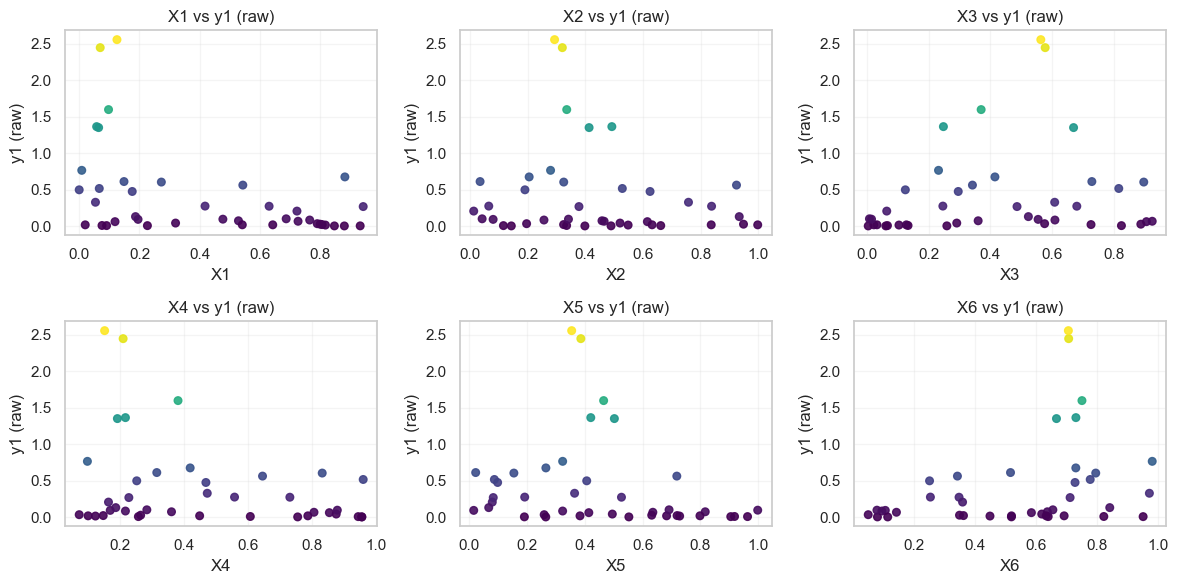

In [75]:
print("\nFeature vs y1 for f7")

# extract inputs and output for f7
input_cols_f7 = [c for c in df_f7.columns if c.startswith("X")]
X_f7 = df_f7[input_cols_f7].values
y_f7 = df_f7["y1"].values

# number of input features (df_f7 has 6)
n_features = X_f7.shape[1]
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# flatten axes safely
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f7):
    ax = axes[j]
    sc = ax.scatter(
        X_f7[:, j],
        y_f7,
        c=y_f7,
        cmap="viridis",
        s=30,
        alpha=0.9
    )
    ax.set_xlabel(col)
    ax.set_ylabel("y1 (raw)")
    ax.set_title(f"{col} vs y1 (raw)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Distribution Analysis

f7 – feature and output distributions


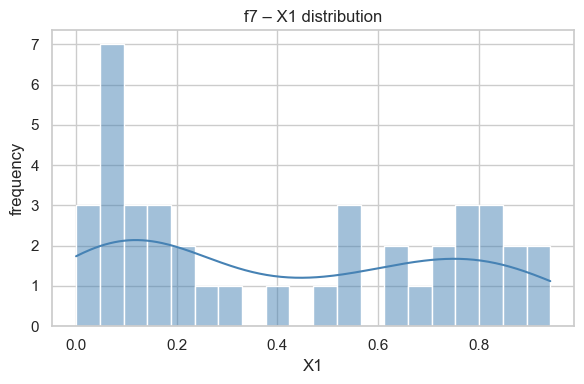

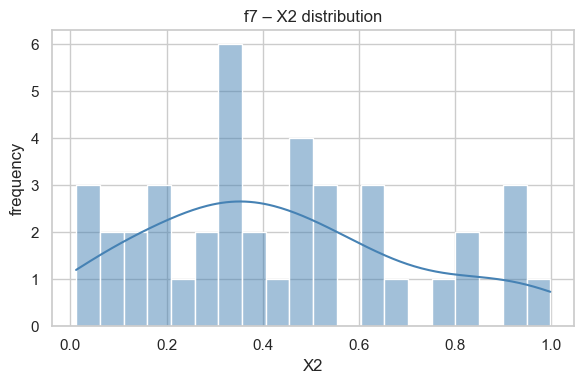

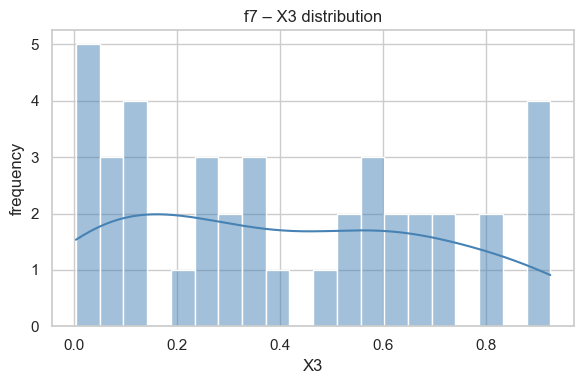

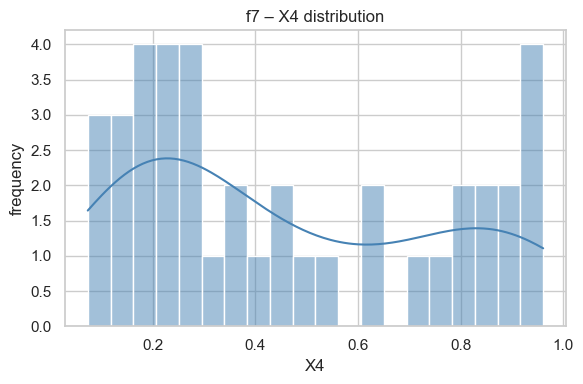

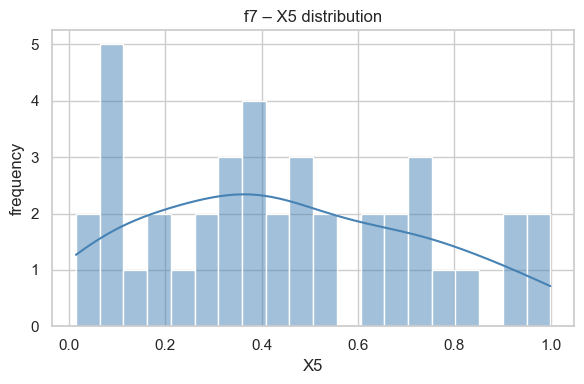

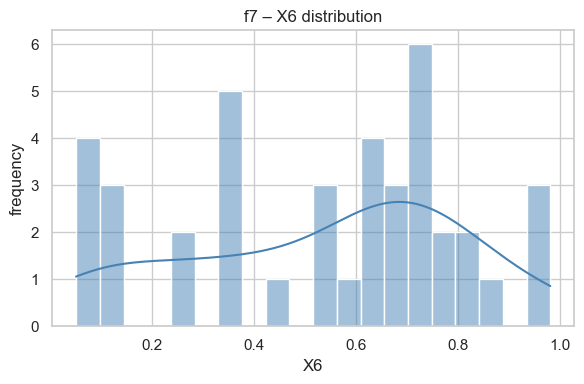

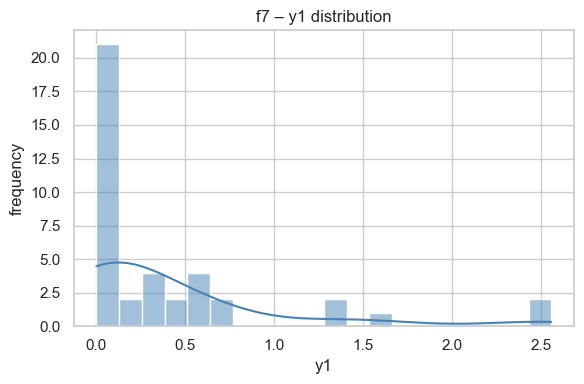

In [76]:
input_cols_f7 = [c for c in df_f7.columns if c.startswith("X")]
output_col_f7 = [c for c in df_f7.columns if c.startswith("y")][0]

print("f7 – feature and output distributions")

all_cols_raw_f7 = input_cols_f7 + [output_col_f7]

for col in all_cols_raw_f7:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f7[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f7 – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()



## Y vs Instance Index

f7 – y vs instance index


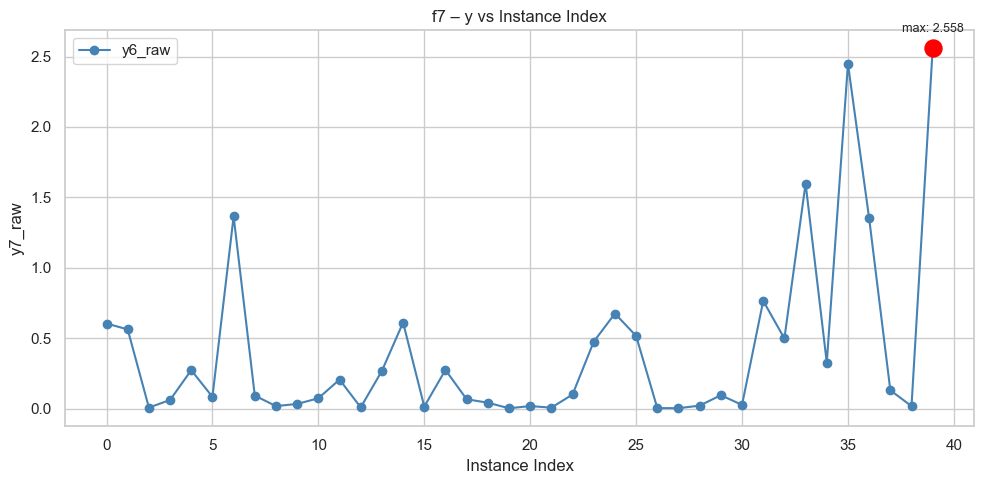

In [77]:
print("f7 – y vs instance index")

# clean copy of raw data
df_f7_plot = df_f7.copy()

# extract raw y
y_raw = df_f7_plot[output_col_f7].values
x = np.arange(len(y_raw))

plt.figure(figsize=(10, 5))

plt.plot(x, y_raw, marker="o", linestyle="-", color="steelblue", label="y6_raw")

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f7 – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("y7_raw")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



## Pearson Correlation

f7 Pearson Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.078636,-0.119959,0.019987,0.071003,-0.509720,-0.445974
X2,-0.078636,1.000000,0.047796,0.138730,0.199331,0.195929,-0.149517
X3,-0.119959,0.047796,1.000000,0.096466,-0.247548,0.107489,0.173878
X4,0.019987,0.138730,0.096466,1.000000,0.100927,-0.068951,-0.291281
X5,0.071003,0.199331,-0.247548,0.100927,1.000000,-0.005142,-0.203132
X6,-0.509720,0.195929,0.107489,-0.068951,-0.005142,1.000000,0.331005
y1,-0.445974,-0.149517,0.173878,-0.291281,-0.203132,0.331005,1.000000


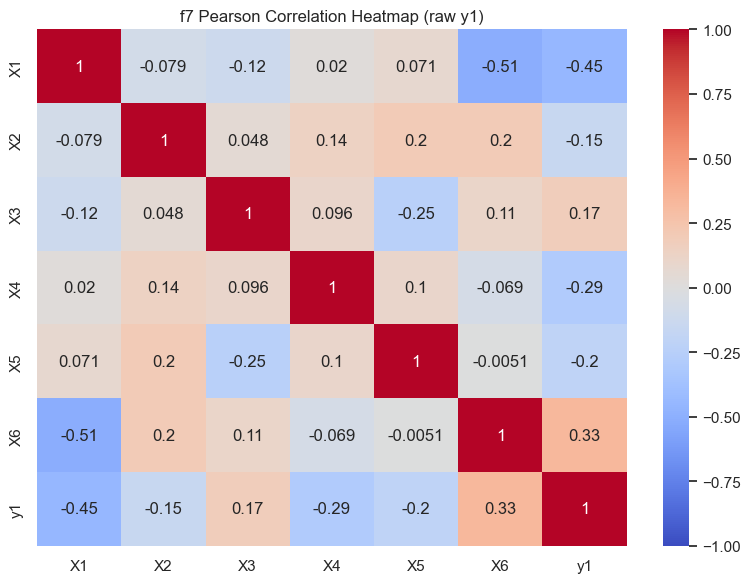

In [78]:
df_raw = df_f7.copy()

print("f7 Pearson Correlation Matrix (raw y1)")

corr_raw = df_raw.corr()
display(corr_raw)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f7 Pearson Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()

## Spearman Correlation

f7 Spearman Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.101501,-0.094934,0.026642,0.025891,-0.472795,-0.455910
X2,-0.101501,1.000000,0.039775,0.196998,0.251407,0.172983,-0.182364
X3,-0.094934,0.039775,1.000000,0.069231,-0.229644,0.151970,0.297373
X4,0.026642,0.196998,0.069231,1.000000,0.104315,-0.028143,-0.249343
X5,0.025891,0.251407,-0.229644,0.104315,1.000000,-0.057786,-0.375235
X6,-0.472795,0.172983,0.151970,-0.028143,-0.057786,1.000000,0.354034
y1,-0.455910,-0.182364,0.297373,-0.249343,-0.375235,0.354034,1.000000


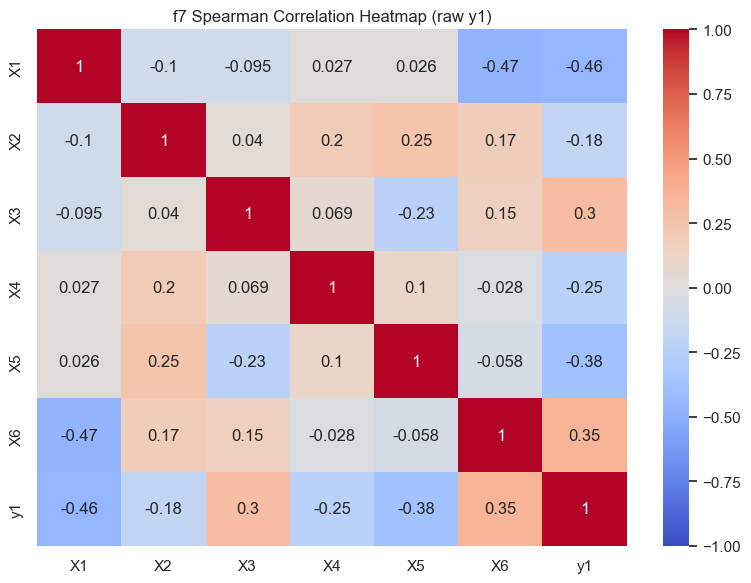

In [79]:
# spearman correlation with raw y1
df_raw = df_f7.copy()

print("f7 Spearman Correlation Matrix (raw y1)")

corr_raw_spearman = df_raw.corr(method="spearman")
display(corr_raw_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f7 Spearman Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Kendall Correlation

f7 Kendall Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,-0.056410,-0.058974,0.010256,0.002564,-0.320513,-0.348718
X2,-0.056410,1.000000,0.028205,0.128205,0.176923,0.094872,-0.133333
X3,-0.058974,0.028205,1.000000,0.017949,-0.148718,0.112821,0.192308
X4,0.010256,0.128205,0.017949,1.000000,0.074359,-0.028205,-0.184615
X5,0.002564,0.176923,-0.148718,0.074359,1.000000,-0.035897,-0.238462
X6,-0.320513,0.094872,0.112821,-0.028205,-0.035897,1.000000,0.223077
y1,-0.348718,-0.133333,0.192308,-0.184615,-0.238462,0.223077,1.000000


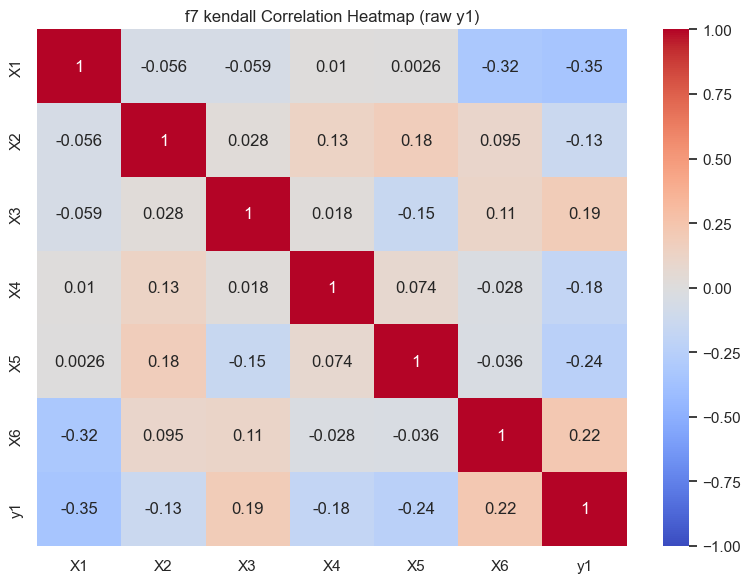

In [80]:
# Kendall correlation with raw y1
df_raw = df_f7.copy()

print("f7 Kendall Correlation Matrix (raw y1)")

corr_raw_kendall = df_raw.corr(method="kendall")
display(corr_raw_kendall)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_kendall,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f7 kendall Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Mutual Information

In [81]:
from sklearn.feature_selection import mutual_info_regression

print("f7 — Mutual Information with Output")

df_f7_raw = df_f7.copy()

# define inputs and output
input_cols_f7 = [c for c in df_f7_raw.columns if c.startswith("X")]
output_col_f7 = "y1"

X_f7 = df_f7_raw[input_cols_f7].values
y_f7 = df_f7_raw[output_col_f7].values

# compute mutual information
mi_f7 = mutual_info_regression(X_f7, y_f7, random_state=42)

# build dataframe
mi_f7_df = pd.DataFrame({
    "Feature": input_cols_f7,
    "Mutual_Info": mi_f7
}).sort_values(by="Mutual_Info", ascending=False)

display(mi_f7_df)


f7 — Mutual Information with Output


,Feature,Mutual_Info
5,X6,0.228736
4,X5,0.128204
0,X1,0.115698
1,X2,0.018426
3,X4,0.017502
2,X3,0.003222


## Partial Correlation

In [82]:
!pip install pingouin
import pingouin as pg

print("f7 (Raw y1) — Partial Correlation")

df_f7_raw = df_f7.copy()

# define inputs and output
input_cols_f7 = [c for c in df_f7_raw.columns if c.startswith("X")]
output_col_f7 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f7:
    covars = [c for c in input_cols_f7 if c != x]  # all other X's as covariates
    
    pcorr_raw_f7 = pg.partial_corr(
        data=df_f7_raw,
        x=x,
        y=output_col_f7,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f7)




Partial correlation for X1:


,n,r,CI95%,p-val
pearson,40,-0.352597,"[-0.61, -0.02]",0.037757



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,40,-0.184208,"[-0.49, 0.16]",0.28946



Partial correlation for X3:


...

,n,r,CI95%,p-val
pearson,40,-0.293771,"[-0.57, 0.04]",0.086735



Partial correlation for X5:


,n,r,CI95%,p-val
pearson,40,-0.102156,"[-0.42, 0.24]",0.559259



Partial correlation for X6:


,n,r,CI95%,p-val
pearson,40,0.153381,"[-0.19, 0.46]",0.379032


## Sliced Inverse Regression


SIR for f7

leading SIR direction (most important 1D projection):
  X1: -0.5876
  X2: -0.0582
  X3: 0.1807
  X4: -0.3498
  X5: -0.4615
  X6: 0.5324

second SIR direction (additional structure):
  X1: -0.1363
  X2: 0.3712
  X3: -0.7357
  X4: -0.0306
  X5: 0.3499
  X6: 0.4231

leading eigenvalues:
  λ1 = 0.7172
  λ2 = 0.4966  (ratio λ2/λ1 = 0.692)

bootstrap stability of leading direction:
  mean angle: 53.72 deg
  std angle:  34.17 deg
  class:      moderately stable
  n_boot:     150


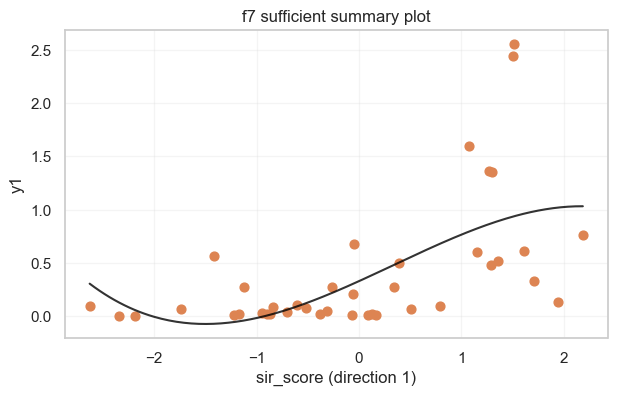

{'sir_dir1': array([-0.5875699 , -0.0581609 ,  0.18071511, -0.34978969, -0.46146425,
         0.53237099]),
 'sir_dir2': array([-0.1362781 ,  0.37123243, -0.73565863, -0.03056973,  0.34994095,
         0.42311697]),
 'eigvals': array([0.71718728, 0.49661313, 0.23876603, 0.17792623, 0.07587826,
        0.05042544]),
 'scores': array([ 1.15546023, -1.41391521, -0.06903709,  0.50482068, -1.11834922,
        -0.83871466,  1.26444864,  0.78609553, -0.38075771, -0.70426801,
        -0.52261747, -0.05665739,  0.09225753,  0.3415306 ,  1.61495781,
        -1.16738272, -0.261142  , -1.73652127, -0.30970745, -2.18440941,
        -0.8651442 ,  0.17018336, -0.60305639,  1.28429543, -0.04564627,
         1.36092252, -1.21843359, -2.34172738, -0.90315895, -2.62993104,
        -0.94319633,  2.18486532,  0.3927193 ,  1.07353963,  1.70358835,
         1.50078096,  1.29695512,  1.94521275,  0.12511281,  1.51602721])}

In [83]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample


# Sliced Inverse Regression (SIR)
# SIR is a dimension-reduction method for regression.
# Instead of modelling y | x, it studies the inverse structure x | y.
# The idea:
#   1. Standardise X.
#   2. Slice y into quantile bins.
#   3. Compute the mean of X in each slice.
#   4. The covariance of these slice means reveals directions in X
#      that are most associated with changes in y.
#   5. Eigenvectors of this covariance give the "effective dimension"
#      directions (EDRs).
#   6. The first direction is the strongest 1D summary of X for predicting y.
#   7. The second direction often carries additional structure.
def sliced_inverse_regression(X, y, n_slices=8):
    # standardise X so all features have mean 0 and variance 1
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    n, p = Xs.shape

    # ensure number of slices is valid
    n_slices = min(max(2, int(n_slices)), max(2, n))

    # slice y into quantile bins
    quantiles = np.linspace(0.0, 1.0, n_slices + 1)
    bins = np.quantile(y, quantiles)
    bins[0] -= 1e-12
    bins[-1] += 1e-12
    slice_idx = np.digitize(y, bins) - 1

    # compute slice means of X and slice probabilities
    slice_means = np.zeros((n_slices, p))
    slice_probs = np.zeros(n_slices)
    for s in range(n_slices):
        mask = slice_idx == s
        if mask.sum() > 0:
            slice_means[s] = Xs[mask].mean(axis=0)
            slice_probs[s] = mask.sum() / n

    # between-slice covariance matrix
    # this captures how X changes as y moves across slices
    cov = np.zeros((p, p))
    for s in range(n_slices):
        m = slice_means[s].reshape(-1, 1)
        cov += slice_probs[s] * (m @ m.T)

    # eigen-decomposition of the covariance
    # eigenvectors = SIR directions
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]

    # normalise directions
    dirs = eigvecs[:, idx]
    dirs = dirs / (np.linalg.norm(dirs, axis=0) + 1e-12)

    # SIR scores = projection of X onto the first direction
    sir_scores = Xs @ dirs[:, 0]

    return dirs, sir_scores, scaler, eigvals[idx]



# Bootstrap stability of the leading SIR direction
# SIR can be unstable at small sample sizes.
# Bootstrap resampling gives a distribution of angles between
# the original SIR direction and bootstrap SIR directions.
# A small angle means stable; a large angle means unstable.
def sir_bootstrap_stability(X, y, n_slices=8, n_boot=100, random_state=0):
    rng = np.random.RandomState(random_state)

    # compute base SIR direction
    base_dirs, _, _, _ = sliced_inverse_regression(X, y, n_slices=n_slices)
    base = base_dirs[:, 0]

    angles = []

    for _ in range(n_boot):
        Xb, yb = resample(X, y, replace=True, random_state=rng)
        try:
            dirs_b, _, _, _ = sliced_inverse_regression(Xb, yb, n_slices=n_slices)
            db = dirs_b[:, 0]

            # angle between base direction and bootstrap direction
            cosang = np.clip(
                np.dot(base, db) /
                (np.linalg.norm(base) * np.linalg.norm(db) + 1e-12),
                -1.0, 1.0
            )
            angles.append(np.arccos(cosang))
        except Exception:
            continue

    angles = np.array(angles)
    mean_deg = np.degrees(np.nanmean(angles))
    std_deg = np.degrees(np.nanstd(angles))

    # stability classification
    if mean_deg < 30:
        cls = "stable"
    elif mean_deg < 60:
        cls = "moderately stable"
    else:
        cls = "unstable"

    return {
        "mean_angle_deg": mean_deg,
        "std_angle_deg": std_deg,
        "class": cls,
        "n_boot": len(angles)
    }



# Main SIR analysis for df_f7
# Includes:
#   - leading and second SIR directions
#   - bootstrap stability classification
#   - polynomial smoothing on the sufficient summary plot

def run_sir_f7(df_f7, n_slices=8, bootstrap_checks=True):
    input_cols = [c for c in df_f7.columns if c.startswith("X")]
    output_col = "y1"

    X = df_f7[input_cols].values.astype(float)
    y = df_f7[output_col].values.astype(float)

    # compute SIR directions
    dirs, sir_scores, scaler, eigvals = sliced_inverse_regression(X, y, n_slices=n_slices)
    sir_dir1 = dirs[:, 0]
    sir_dir2 = dirs[:, 1]

    print("\nSIR for f7")

    # print leading direction
    print("\nleading SIR direction (most important 1D projection):")
    for col, v in zip(input_cols, sir_dir1):
        print(f"  {col}: {v:.4f}")

    # print second direction
    print("\nsecond SIR direction (additional structure):")
    for col, v in zip(input_cols, sir_dir2):
        print(f"  {col}: {v:.4f}")

    # eigenvalues show how much variance each direction explains
    print("\nleading eigenvalues:")
    print(f"  λ1 = {eigvals[0]:.4f}")
    print(f"  λ2 = {eigvals[1]:.4f}  (ratio λ2/λ1 = {eigvals[1]/eigvals[0]:.3f})")

    # bootstrap stability
    if bootstrap_checks:
        stab = sir_bootstrap_stability(X, y, n_slices=n_slices, n_boot=150)
        print("\nbootstrap stability of leading direction:")
        print(f"  mean angle: {stab['mean_angle_deg']:.2f} deg")
        print(f"  std angle:  {stab['std_angle_deg']:.2f} deg")
        print(f"  class:      {stab['class']}")
        print(f"  n_boot:     {stab['n_boot']}")

    # sufficient summary plot
    plt.figure(figsize=(7,4))
    plt.scatter(sir_scores, y, c="C1", s=40)
    plt.xlabel("sir_score (direction 1)")
    plt.ylabel("y1")
    plt.title("f7 sufficient summary plot")
    plt.grid(alpha=0.2)

    # polynomial smoothing (degree 3)
    try:
        coeffs = np.polyfit(sir_scores, y, 3)
        xs = np.linspace(sir_scores.min(), sir_scores.max(), 200)
        ys = np.polyval(coeffs, xs)
        plt.plot(xs, ys, color="black", linewidth=1.5, alpha=0.8)
    except Exception:
        pass

    plt.show()

    return {
        "sir_dir1": sir_dir1,
        "sir_dir2": sir_dir2,
        "eigvals": eigvals,
        "scores": sir_scores
    }


run_sir_f7(df_f7, n_slices=8, bootstrap_checks=True)

## 2D Geodesic Embedding

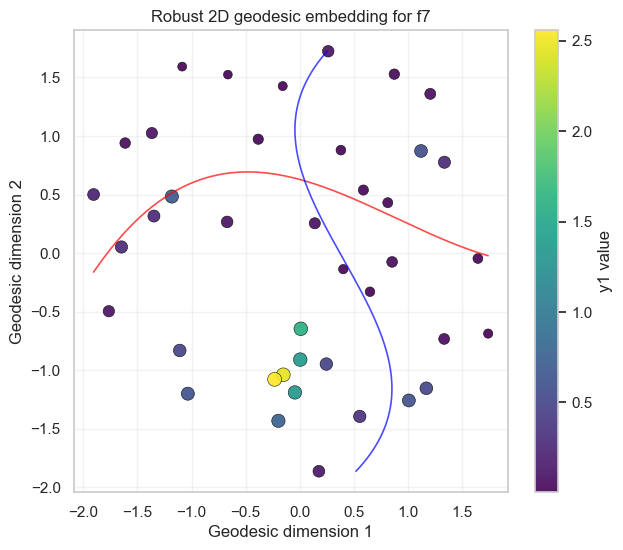

{'embedding': array([[ 1.01042029, -1.25912439],
        [ 1.12282482,  0.87211507],
        [ 0.40335783, -0.13739271],
        [ 1.33675469, -0.73359374],
        [ 1.33938504,  0.7759421 ],
        [-1.36687629,  1.02528881],
        [ 0.00559083, -0.91001891],
        [-1.76492073, -0.49669482],
        [ 0.815301  ,  0.4304254 ],
        [-1.61393321,  0.93988911],
        [ 0.14026774,  0.25436551],
        [-1.90593729,  0.50016046],
        [ 0.65062499, -0.33038253],
        [-1.34787019,  0.31615818],
        [-1.03423362, -1.20124016],
        [ 0.38143193,  0.87951616],
        [-1.6481628 ,  0.05202437],
        [ 1.20833335,  1.3601806 ],
        [ 0.85535167, -0.0756013 ],
        [-0.66386771,  1.52432528],
        [ 0.58967588,  0.53846508],
        [ 1.74374157, -0.68782602],
        [-0.6707331 ,  0.26622471],
        [ 0.24708114, -0.94807459],
        [-1.18197497,  0.48299373],
        [ 1.17209534, -1.15519908],
        [-0.1565607 ,  1.42657856],
        [-1.086

In [84]:
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS


def robust_isomap_2d(X, k=6, eps_factor=0.25):
    """
    Robust Isomap-like embedding that never fails.
    Builds a hybrid graph:
      - k-NN edges
      - epsilon-radius edges (eps = eps_factor * median distance)
    Ensures graph connectivity and computes geodesic distances.
    Uses classical MDS to obtain a 2D embedding.
    """

    # standardise X
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # pairwise distances
    D = pairwise_distances(Xs)

    # k-NN graph
    n = len(X)
    knn_graph = np.full((n, n), np.inf)
    for i in range(n):
        idx = np.argsort(D[i])[1:k+1]
        knn_graph[i, idx] = D[i, idx]
        knn_graph[idx, i] = D[idx, i]

    # epsilon graph to guarantee connectivity
    eps = eps_factor * np.median(D)
    eps_graph = np.where(D <= eps, D, np.inf)

    # hybrid graph
    G = np.minimum(knn_graph, eps_graph)

    # Floyd–Warshall for geodesic distances
    geo = G.copy()
    for k in range(n):
        geo = np.minimum(geo, geo[:, k][:, None] + geo[k, :][None, :])

    # classical MDS on geodesic distances
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0)
    emb = mds.fit_transform(geo)

    # standardise embedding
    emb = (emb - emb.mean(axis=0)) / (emb.std(axis=0) + 1e-12)

    return emb, scaler, geo


def run_isomap_f7(df_f7):
    input_cols = [c for c in df_f7.columns if c.startswith("X")]
    X = df_f7[input_cols].values.astype(float)
    y = df_f7["y1"].values.astype(float)

    ranks = np.argsort(np.argsort(y))
    sizes = 40 + 60 * (ranks / ranks.max())

    # robust embedding
    emb, scaler, geo = robust_isomap_2d(X, k=6, eps_factor=0.25)

    # plot
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(
        emb[:, 0], emb[:, 1],
        c=y, s=sizes,
        cmap="viridis",
        alpha=0.9,
        edgecolor="black",
        linewidth=0.4
    )
    plt.xlabel("Geodesic dimension 1")
    plt.ylabel("Geodesic dimension 2")
    plt.title("Robust 2D geodesic embedding for f7")
    plt.grid(alpha=0.25)
    plt.colorbar(sc, label="y1 value")

    # polynomial smoothing along each axis
    try:
        coeffs_x = np.polyfit(emb[:, 0], y, 3)
        xs = np.linspace(emb[:, 0].min(), emb[:, 0].max(), 200)
        ys = np.polyval(coeffs_x, xs)
        plt.plot(xs, ys, color="red", linewidth=1.2, alpha=0.7)
    except Exception:
        pass

    try:
        coeffs_y = np.polyfit(emb[:, 1], y, 3)
        ys2 = np.linspace(emb[:, 1].min(), emb[:, 1].max(), 200)
        xs2 = np.polyval(coeffs_y, ys2)
        plt.plot(xs2, ys2, color="blue", linewidth=1.2, alpha=0.7)
    except Exception:
        pass

    plt.show()

    return {"embedding": emb, "geodesic_distances": geo, "scaler": scaler}


run_isomap_f7(df_f7)

## K means Clustering


K-means clustering for df_f7 (focused high-value analysis)

high-value cluster: 2
mean y1 in this cluster: 1.103785

members of high-value cluster (row indices):
[6, 23, 31, 33, 34, 35, 36, 37, 38, 39]

centroid of high-value cluster (6D):
         X1        X2        X3        X4        X5        X6
0  0.086011  0.544534  0.421322  0.317605  0.336314  0.760496

within-cluster variance per dimension:
  dimension  within_cluster_variance
0        X1                 0.003286
1        X2                 0.065845
2        X3                 0.032256
3        X4                 0.040136
4        X5                 0.018655
5        X6                 0.017391


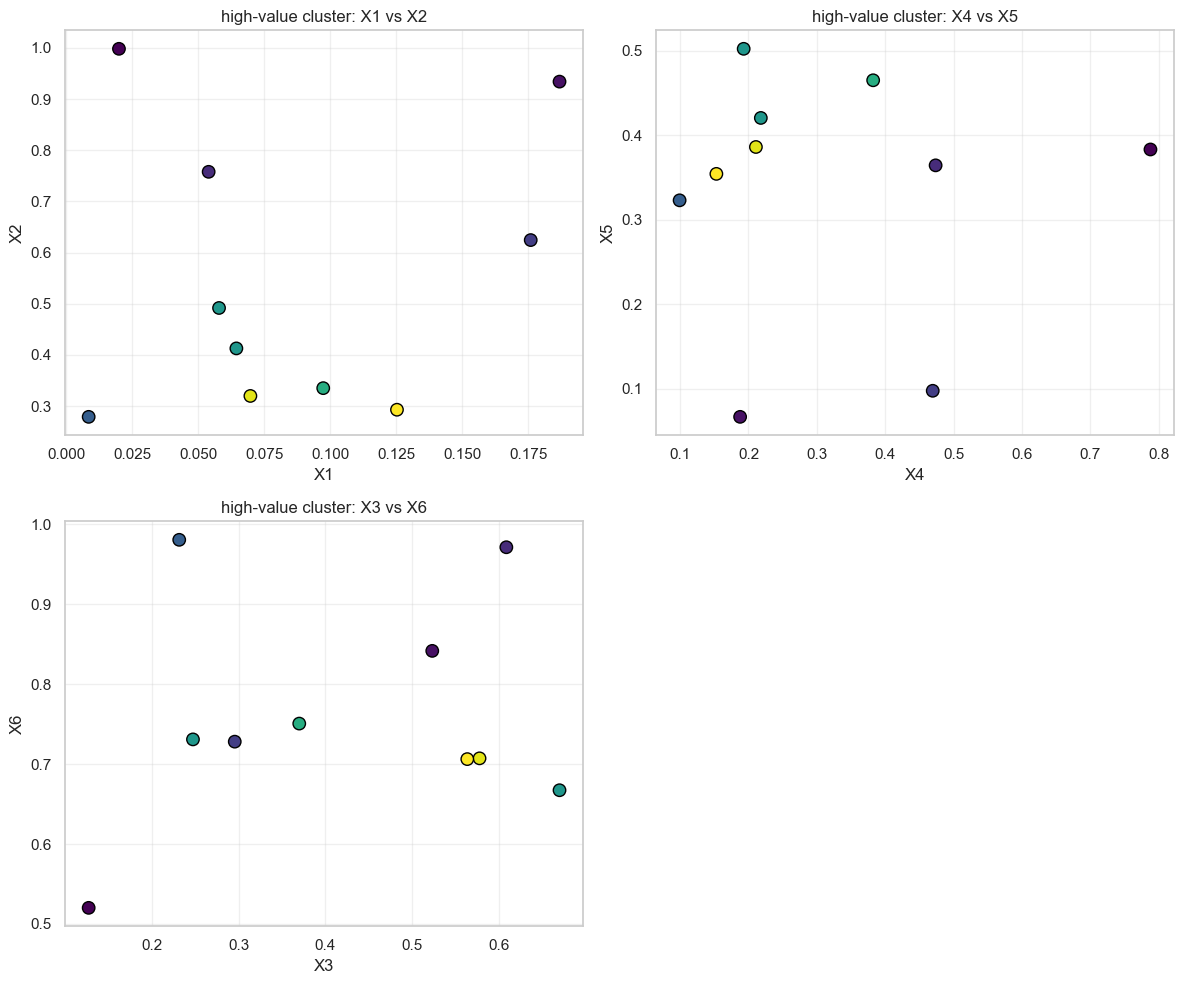

In [85]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# focused k-means clustering for df_f7 with emphasis on the high-value cluster

print("\nK-means clustering for df_f7 (focused high-value analysis)")

# extract input and output columns
input_cols = [col for col in df_f7.columns if col.startswith("X")]
output_col = "y1"

# convert to arrays
X_f7 = df_f7[input_cols].values.astype(float)
y_f7 = df_f7[output_col].values.astype(float)

# run k-means with k=6 (confirmed optimal)
k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_f7)

# assign cluster labels
labels = kmeans.labels_
df_f7["cluster"] = labels

# compute mean y1 for each cluster
cluster_means = df_f7.groupby("cluster")[output_col].mean()

# identify the cluster with the highest mean y1
high_cluster = cluster_means.idxmax()
print(f"\nhigh-value cluster: {high_cluster}")
print(f"mean y1 in this cluster: {cluster_means[high_cluster]:.6f}")

# list the row indices belonging to the high-value cluster
members = df_f7.index[df_f7["cluster"] == high_cluster].tolist()
print("\nmembers of high-value cluster (row indices):")
print(members)

# extract the centroid of the high-value cluster
centroid = kmeans.cluster_centers_[high_cluster]
centroid_df = pd.DataFrame([centroid], columns=input_cols)
print("\ncentroid of high-value cluster (6D):")
print(centroid_df)

# compute within-cluster variance for each dimension
X_cluster = X_f7[df_f7["cluster"] == high_cluster]
var_within = X_cluster.var(axis=0)

var_df = pd.DataFrame({
    "dimension": input_cols,
    "within_cluster_variance": var_within
})
print("\nwithin-cluster variance per dimension:")
print(var_df)

# scatter plots showing only the high-value cluster members
plt.figure(figsize=(12, 10))

# choose three informative feature pairs
pairs = [(0, 1), (3, 4), (2, 5)]  # X1 vs X2, X4 vs X5, X3 vs X6

for i, (a, b) in enumerate(pairs, 1):
    plt.subplot(2, 2, i)
    plt.scatter(
        X_cluster[:, a],
        X_cluster[:, b],
        c=y_f7[df_f7["cluster"] == high_cluster],
        cmap="viridis",
        s=80,
        edgecolor="black"
    )
    plt.xlabel(input_cols[a])
    plt.ylabel(input_cols[b])
    plt.title(f"high-value cluster: {input_cols[a]} vs {input_cols[b]}")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



## Active Subspace Detection via Gradient-Based Dimension Reduction

**Reference:** Constantine, P.G., Dow, E. and Wang, Q. (2014) 'Active subspace methods in theory and practice: applications to kriging surfaces', SIAM Journal on Scientific Computing, 36(4), pp. A1500–A1524. Available at: https://doi.org/10.1137/130916138

- Used for f7 because the function has 6 input dimensions but the EDA consistently shows only 3 dimensions (X1, X5, X6) carrying meaningful signal, and active subspace detection quantifies how many effective dimensions the function has near the current best by decomposing the average squared gradient matrix, directly informing whether the trust region should be a hyper-rectangle or an oriented ellipsoid aligned with the true directions of variation.


active subspace detection
eigenvalues (top 4): [4.6764 1.3025 0.5515 0.1239]
consecutive eigenvalue ratios: [0.2785 0.4234 0.2247]
effective dimensionality estimate:
  function appears effectively 5d (ratio 0.001 < 0.20)

leading active subspace direction (w1):
  X1: -0.0244
  X2: -0.5689
  X3: 0.0037
  X4: -0.1577
  X5: -0.7958
  X6: -0.1322

second active subspace direction (w2):
  X1: -0.0168
  X2: -0.0313
  X3: 0.0023
  X4: -0.0156
  X5: 0.1889
  X6: -0.9812


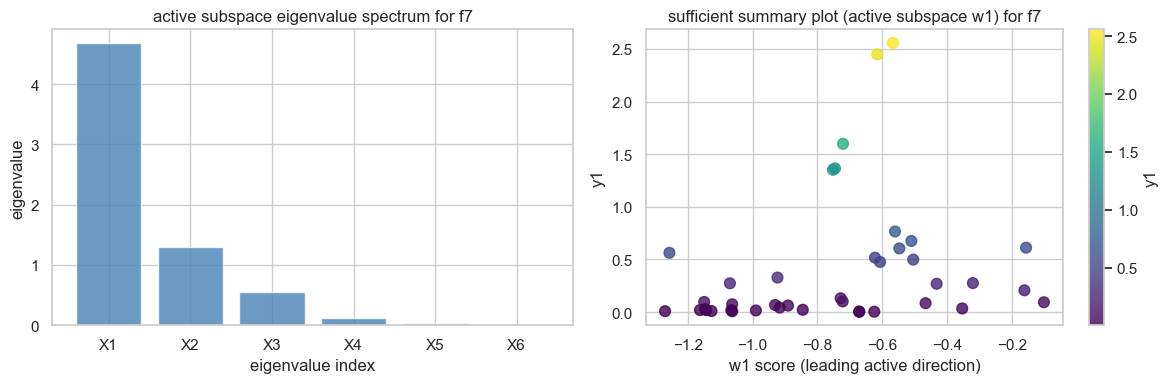

In [86]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.linear_model import LinearRegression

# method: active subspace detection via finite differences
# source: high-dimensional bo survey (neurips 2024) and dimension_reduction.pdf
# estimates the matrix of average squared directional derivatives
# using finite differences on existing observations
# eigenvalues rank how much variance each direction explains
# eigenvectors define the active subspace directions

def compute_active_subspace(df, feature_cols, target_col, delta=0.05):
    """
    estimates the active subspace of the function using finite differences.
    the active subspace is the low-dimensional subspace where the function
    varies most, identified by the dominant eigenvectors of the matrix
    c = e[grad f * grad f^t], approximated from finite differences.

    parameters
    ----------
    df : dataframe containing features and target
    feature_cols : list of input column names
    target_col : output column name
    delta : finite difference step size (default 0.05)
    """

    X = df[feature_cols].values
    y = df[target_col].values
    n, d = X.shape

    # fit a gp to approximate the function for finite difference computation
    # matern 2.5 with ard is used to respect per-dimension length scales
    kernel = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(d),
        length_scale_bounds=[(0.05, 5.0)] * d,
        nu=2.5
    ) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.1))

    gp = GPR(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
    gp.fit(X, y)

    # compute finite difference gradient at each observed point
    # grad_f[i, j] = (f(x + delta*e_j) - f(x - delta*e_j)) / (2*delta)
    # this is the central difference approximation of the partial derivative
    grad_matrix = np.zeros((n, d))

    for i in range(n):
        for j in range(d):
            x_plus = X[i].copy()
            x_minus = X[i].copy()
            x_plus[j] = np.clip(X[i, j] + delta, 0.0, 1.0)
            x_minus[j] = np.clip(X[i, j] - delta, 0.0, 1.0)

            f_plus = gp.predict(x_plus.reshape(1, -1))[0]
            f_minus = gp.predict(x_minus.reshape(1, -1))[0]

            # use actual delta after clipping
            actual_delta = x_plus[j] - x_minus[j]
            if actual_delta > 1e-8:
                grad_matrix[i, j] = (f_plus - f_minus) / actual_delta
            else:
                grad_matrix[i, j] = 0.0

    # active subspace matrix c = (1/n) * sum_i grad_i * grad_i^t
    # shape (d, d), symmetric positive semidefinite
    C_matrix = (grad_matrix.T @ grad_matrix) / n

    # eigendecomposition: eigenvalues in descending order
    eigenvalues, eigenvectors = np.linalg.eigh(C_matrix)
    sort_idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sort_idx]
    eigenvectors = eigenvectors[:, sort_idx]

    # eigenvalue ratio: consecutive ratio < 0.1 indicates effective dimensionality
    # e.g. if eigenvalue[1] / eigenvalue[0] < 0.1, function is effectively 1d
    ratios = eigenvalues[1:] / (eigenvalues[:-1] + 1e-12)

    print("\nactive subspace detection")
    print(f"eigenvalues (top {min(d, 4)}): {eigenvalues[:4].round(4)}")
    print(f"consecutive eigenvalue ratios: {ratios[:3].round(4)}")
    print("effective dimensionality estimate:")
    for k in range(1, d):
        if ratios[k-1] < 0.20:
            print(f"  function appears effectively {k}d (ratio {ratios[k-1]:.3f} < 0.20)")
            break
    else:
        print(f"  function appears effectively {d}d (no clear eigenvalue gap)")

    print("\nleading active subspace direction (w1):")
    for i, col in enumerate(feature_cols):
        print(f"  {col}: {eigenvectors[i, 0]:.4f}")

    print("\nsecond active subspace direction (w2):")
    for i, col in enumerate(feature_cols):
        print(f"  {col}: {eigenvectors[i, 1]:.4f}")

    # plot eigenvalue spectrum
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(range(1, d+1), eigenvalues, color="steelblue", alpha=0.8)
    axes[0].set_xlabel("eigenvalue index")
    axes[0].set_ylabel("eigenvalue")
    axes[0].set_title("active subspace eigenvalue spectrum for f7")
    axes[0].set_xticks(range(1, d+1))
    axes[0].set_xticklabels(feature_cols)

    # sufficient summary plot along leading active subspace direction
    active_scores = X @ eigenvectors[:, 0]
    axes[1].scatter(active_scores, y, c=y, cmap="viridis", s=60, alpha=0.8)
    axes[1].set_xlabel("w1 score (leading active direction)")
    axes[1].set_ylabel("y1")
    axes[1].set_title("sufficient summary plot (active subspace w1) for f7")
    plt.colorbar(axes[1].collections[0], ax=axes[1], label="y1")

    plt.tight_layout()
    plt.show()

    return eigenvalues, eigenvectors, grad_matrix


eigenvalues_f7, eigenvectors_f7, grad_f7 = compute_active_subspace(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1"
)

## Local Linear Embedding of the High-Value Neighbourhood


**Reference:** Roweis, S.T. and Saul, L.K. (2000) 'Nonlinear dimensionality reduction by locally linear embedding', Science, 290(5500), pp. 2323–2326. Available at: https://doi.org/10.1126/science.290.5500.2323

- Used for f7 because the global SIR direction has bootstrap stability angles between 53 and 79 degrees across weeks, indicating it is only moderately reliable, and a local linear fit restricted to the top-10 observations produces a gradient direction specific to the confirmed high-value neighbourhood rather than the full dataset, making it more trustworthy for acquisition guidance in the exploitation phase.


local linear gradient (top 10 observations)
y range in local neighbourhood: [0.5628, 2.5580]
observations included:
  idx=39: y=2.5580
  idx=35: y=2.4483
  idx=33: y=1.5985
  idx=6: y=1.3650
  idx=36: y=1.3516
  idx=31: y=0.7654
  idx=24: y=0.6751
  idx=14: y=0.6115
  idx=0: y=0.6044
  idx=1: y=0.5628

local linear model r2: 0.5383
local gradient direction (standardised coefficients):
  X1: -0.1079  (normalised: -0.1184)  -> decrease
  X2: -0.4061  (normalised: -0.4454)  -> decrease
  X3: 0.3222  (normalised: 0.3534)  -> increase
  X4: -0.2874  (normalised: -0.3152)  -> decrease
  X5: 0.6826  (normalised: 0.7487)  -> increase
  X6: 0.0480  (normalised: 0.0526)  -> increase

local gradient vs sir: positive = agree, negative = disagree
  X1: dot product = 0.0696  (agree)
  X2: dot product = 0.0259  (agree)
  X3: dot product = 0.0639  (agree)
  X4: dot product = 0.1103  (agree)
  X5: dot product = -0.3455  (DISAGREE)
  X6: dot product = 0.0280  (agree)


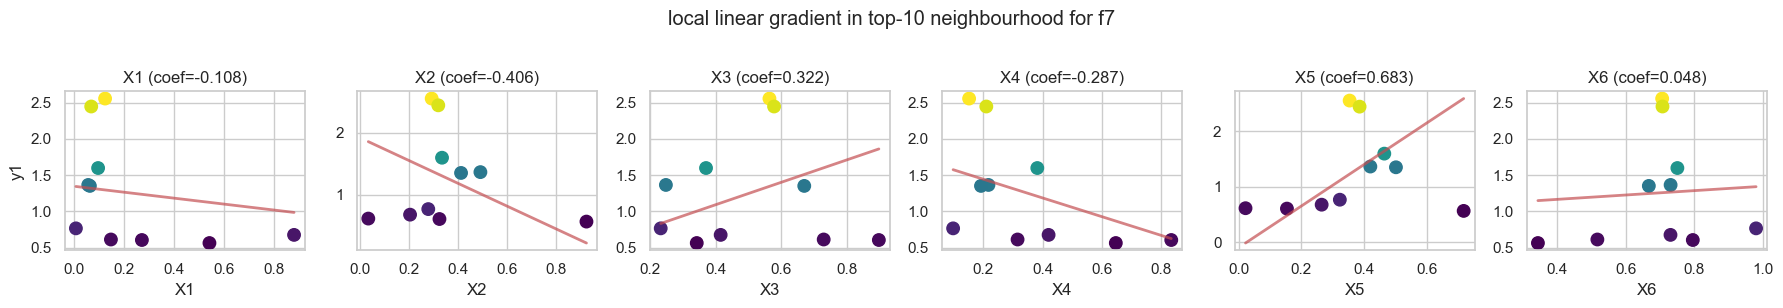

In [87]:
# method: local linear embedding of high-value neighbourhood
# source: dimension_reduction.pdf and latent_space.pdf
# fits a local linear model to the top-n observations only
# the coefficients give the local gradient direction near the peak
# more reliable than sir at small n because it focuses on the
# high-value region rather than the full dataset


def local_linear_gradient(df, feature_cols, target_col, top_n=10):
    """
    fits a local linear model to the top-n observations by y value.
    the regression coefficients approximate the local gradient direction
    in the neighbourhood of the current best observations.
    this direction can replace or augment the sir direction as the
    acquisition boost in the trust region ensemble.

    parameters
    ----------
    df : dataframe containing features and target
    feature_cols : list of input column names
    target_col : output column name
    top_n : number of top observations to include in local fit
    """

    # select top-n observations by y value
    df_sorted = df.nlargest(top_n, target_col)
    X_local = df_sorted[feature_cols].values
    y_local = df_sorted[target_col].values

    print(f"\nlocal linear gradient (top {top_n} observations)")
    print(f"y range in local neighbourhood: [{y_local.min():.4f}, {y_local.max():.4f}]")
    print("observations included:")
    for idx in df_sorted.index:
        row = df_sorted.loc[idx]
        print(f"  idx={idx}: y={row[target_col]:.4f}")

    # standardise inputs for comparable coefficients
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_local)

    # fit local linear model
    # coefficients give the direction of steepest ascent in the local neighbourhood
    lr = LinearRegression()
    lr.fit(X_scaled, y_local)

    coefs = lr.coef_
    coef_norm = coefs / (np.linalg.norm(coefs) + 1e-12)

    print(f"\nlocal linear model r2: {lr.score(X_scaled, y_local):.4f}")
    print("local gradient direction (standardised coefficients):")
    for i, col in enumerate(feature_cols):
        direction = "increase" if coefs[i] > 0 else "decrease"
        print(f"  {col}: {coefs[i]:.4f}  (normalised: {coef_norm[i]:.4f})  -> {direction}")

    # compare with sir direction if available
    print("\nlocal gradient vs sir: positive = agree, negative = disagree")
    sir_direction = np.array([-0.5876, -0.0582, 0.1807, -0.3498, -0.4615, 0.5324])
    agreement = coef_norm * sir_direction
    for i, col in enumerate(feature_cols):
        symbol = "agree" if agreement[i] > 0 else "DISAGREE"
        print(f"  {col}: dot product = {agreement[i]:.4f}  ({symbol})")

    # plot local linear fit: actual vs predicted in local neighbourhood
    fig, axes = plt.subplots(1, len(feature_cols), figsize=(18, 3))
    for i, col in enumerate(feature_cols):
        axes[i].scatter(X_local[:, i], y_local, c=y_local, cmap="viridis", s=80)
        # overlay linear fit line
        x_range = np.linspace(X_local[:, i].min(), X_local[:, i].max(), 50)
        x_full = np.tile(X_local.mean(axis=0), (50, 1))
        x_full[:, i] = x_range
        x_full_scaled = scaler.transform(x_full)
        y_pred = lr.predict(x_full_scaled)
        axes[i].plot(x_range, y_pred, "r-", linewidth=2, alpha=0.7)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("y1" if i == 0 else "")
        axes[i].set_title(f"{col} (coef={coefs[i]:.3f})")

    plt.suptitle(f"local linear gradient in top-{top_n} neighbourhood for f7", y=1.02)
    plt.tight_layout()
    plt.show()

    return coefs, coef_norm, lr, scaler


local_coefs_f7, local_coef_norm_f7, local_lr_f7, local_scaler_f7 = local_linear_gradient(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1",
    top_n=10
)

## GP Posterior Variance Decomposition by Dimension

**Reference:** Rasmussen, C.E. and Williams, C.K.I. (2006) Gaussian Processes for Machine Learning. Cambridge, MA: MIT Press. Available at: http://www.gaussianprocess.org/gpml/

- Used for f7 because the week 9 failure was caused by pure variance maximisation selecting a point at X2=0.998 in a topologically disconnected low-value region, and variance decomposition at the incumbent identifies which dimensions have high posterior uncertainty in directions that also have positive mean gradient, separating informative uncertainty from irrelevant uncertainty in unexplored low-value regions.


gp posterior variance decomposition
fitted kernel: 0.74**2 * Matern(length_scale=[0.667, 0.311, 5, 0.635, 0.226, 0.224], nu=2.5) + WhiteKernel(noise_level=1e-06)

incumbent: idx=39, y=2.5580
posterior std at incumbent: 0.000878

variance sensitivity (change in posterior std per dimension):
high sensitivity = gp is most uncertain in this direction
  X1: delta_sigma=0.035027  mean_grad=-0.6580  sigma+=0.0356  sigma-=0.0359
  X2: delta_sigma=0.073662  mean_grad=-1.0396  sigma+=0.0629  sigma-=0.0745
  X3: delta_sigma=0.005062  mean_grad=0.0156  sigma+=0.0059  sigma-=0.0059
  X4: delta_sigma=0.036139  mean_grad=-0.1996  sigma+=0.0355  sigma-=0.0370
  X5: delta_sigma=0.092401  mean_grad=-0.0886  sigma+=0.0767  sigma-=0.0933
  X6: delta_sigma=0.107676  mean_grad=-0.9060  sigma+=0.0991  sigma-=0.1086

dimensions ranked by variance sensitivity (most to least):
  rank 1: X6 (sensitivity=0.107676, mean_grad=-0.9060)
  rank 2: X5 (sensitivity=0.092401, mean_grad=-0.0886)
  rank 3: X2 (sensitivity

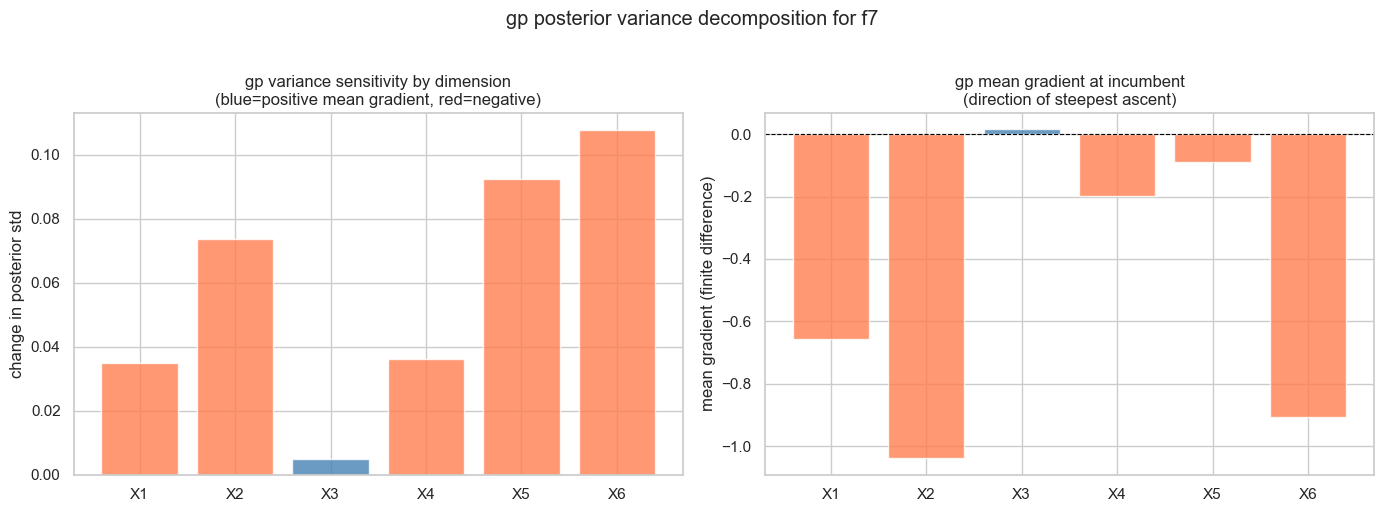

In [88]:
# method: gp posterior variance decomposition by dimension
# source: regularised.pdf and automl.pdf (ard kernel diagnostics)
# measures how much posterior variance changes when each dimension
# is perturbed from the incumbent by a fixed delta
# the dimension with largest variance change is most informative
# this directly catches the week 9 failure mode: high variance
# in x2 and x4 was in a low-y region, not near the peak
def gp_variance_decomposition(df, feature_cols, target_col, delta=0.05):
    """
    computes gp posterior variance decomposition by dimension.
    for each dimension, measures how much the posterior variance changes
    when the incumbent is perturbed by delta in that dimension.
    high sensitivity = gp is uncertain in that direction = informative to explore.
    cross-referenced with y values to distinguish high-uncertainty-high-y
    regions from high-uncertainty-low-y regions.

    parameters
    ----------
    df : dataframe containing features and target
    feature_cols : list of input column names
    target_col : output column name
    delta : perturbation size for finite difference (default 0.05)
    """

    X = df[feature_cols].values
    y = df[target_col].values
    n, d = X.shape

    # fit ard-gp on full dataset
    kernel = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(d),
        length_scale_bounds=[(0.05, 5.0)] * d,
        nu=2.5
    ) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.1))

    gp = GPR(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
    gp.fit(X, y)

    print("\ngp posterior variance decomposition")
    print(f"fitted kernel: {gp.kernel_}")

    # incumbent: point with highest observed y
    incumbent_idx = np.argmax(y)
    incumbent = X[incumbent_idx].copy()
    _, sigma_incumbent = gp.predict(incumbent.reshape(1, -1), return_std=True)
    print(f"\nincumbent: idx={incumbent_idx}, y={y[incumbent_idx]:.4f}")
    print(f"posterior std at incumbent: {sigma_incumbent[0]:.6f}")

    # variance sensitivity per dimension
    # for each dim j, perturb incumbent by +delta and -delta
    # record the change in posterior std
    var_sensitivity = np.zeros(d)
    mean_sensitivity = np.zeros(d)
    sigma_plus = np.zeros(d)
    sigma_minus = np.zeros(d)
    mu_plus = np.zeros(d)
    mu_minus = np.zeros(d)

    for j in range(d):
        x_plus = incumbent.copy()
        x_minus = incumbent.copy()
        x_plus[j] = np.clip(incumbent[j] + delta, 0.0, 1.0)
        x_minus[j] = np.clip(incumbent[j] - delta, 0.0, 1.0)

        mu_p, sig_p = gp.predict(x_plus.reshape(1, -1), return_std=True)
        mu_m, sig_m = gp.predict(x_minus.reshape(1, -1), return_std=True)

        sigma_plus[j] = sig_p[0]
        sigma_minus[j] = sig_m[0]
        mu_plus[j] = mu_p[0]
        mu_minus[j] = mu_m[0]

        # variance sensitivity: max change in std relative to incumbent std
        var_sensitivity[j] = max(
            abs(sig_p[0] - sigma_incumbent[0]),
            abs(sig_m[0] - sigma_incumbent[0])
        )
        mean_sensitivity[j] = (mu_p[0] - mu_m[0]) / (2 * delta + 1e-12)

    print("\nvariance sensitivity (change in posterior std per dimension):")
    print("high sensitivity = gp is most uncertain in this direction")
    for j, col in enumerate(feature_cols):
        print(f"  {col}: delta_sigma={var_sensitivity[j]:.6f}  "
              f"mean_grad={mean_sensitivity[j]:.4f}  "
              f"sigma+={sigma_plus[j]:.4f}  sigma-={sigma_minus[j]:.4f}")

    # rank dimensions by variance sensitivity
    rank_order = np.argsort(var_sensitivity)[::-1]
    print("\ndimensions ranked by variance sensitivity (most to least):")
    for rank, j in enumerate(rank_order):
        print(f"  rank {rank+1}: {feature_cols[j]} "
              f"(sensitivity={var_sensitivity[j]:.6f}, "
              f"mean_grad={mean_sensitivity[j]:.4f})")

    # plot variance decomposition
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x_pos = np.arange(d)
    bar_colors = ["steelblue" if mean_sensitivity[j] > 0 else "coral"
                  for j in range(d)]

    axes[0].bar(x_pos, var_sensitivity[np.arange(d)],
                color=bar_colors, alpha=0.8)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(feature_cols)
    axes[0].set_ylabel("change in posterior std")
    axes[0].set_title("gp variance sensitivity by dimension\n"
                      "(blue=positive mean gradient, red=negative)")

    # mean sensitivity plot
    colors_mean = ["steelblue" if v > 0 else "coral" for v in mean_sensitivity]
    axes[1].bar(x_pos, mean_sensitivity, color=colors_mean, alpha=0.8)
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(feature_cols)
    axes[1].set_ylabel("mean gradient (finite difference)")
    axes[1].set_title("gp mean gradient at incumbent\n"
                      "(direction of steepest ascent)")

    plt.suptitle("gp posterior variance decomposition for f7", y=1.02)
    plt.tight_layout()
    plt.show()

    return var_sensitivity, mean_sensitivity, gp


var_sens_f7, mean_sens_f7, gp_f7 = gp_variance_decomposition(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1"
)

## Expected Improvement Contour Along Top-2 SIR Dimensions

**Reference:** Diessner, M., O'Connor, J., Wynn, A., Laizet, S., Gumerov, N., Agarwal, R. and Whalley, R.D. (2022) 'Investigating Bayesian optimization for expensive-to-evaluate black box functions: application in fluid dynamics', Frontiers in Applied Mathematics and Statistics, 8, article 1076296. Available at: https://doi.org/10.3389/fams.2022.1076296

- Used for f7 because the NUBO paper explicitly validates EI surface visualisation as a diagnostic for low-budget expensive function optimisation, and plotting the EI contour over the X1–X6 plane with all other dimensions fixed at the incumbent directly answers whether the next query should move X1 lower or X6 higher, the two dimensions with the strongest SIR loadings and the most consistent EDA signal across all eleven weeks.


expected improvement contour for f7
incumbent: idx=39, y=2.5580
sweeping X1 (dim 0) vs X6 (dim 5)
all other dimensions fixed at incumbent values

maximum ei at: X1=0.0169, X6=0.6949
ei value at maximum: 0.041178
gp mean at ei maximum: 2.5746


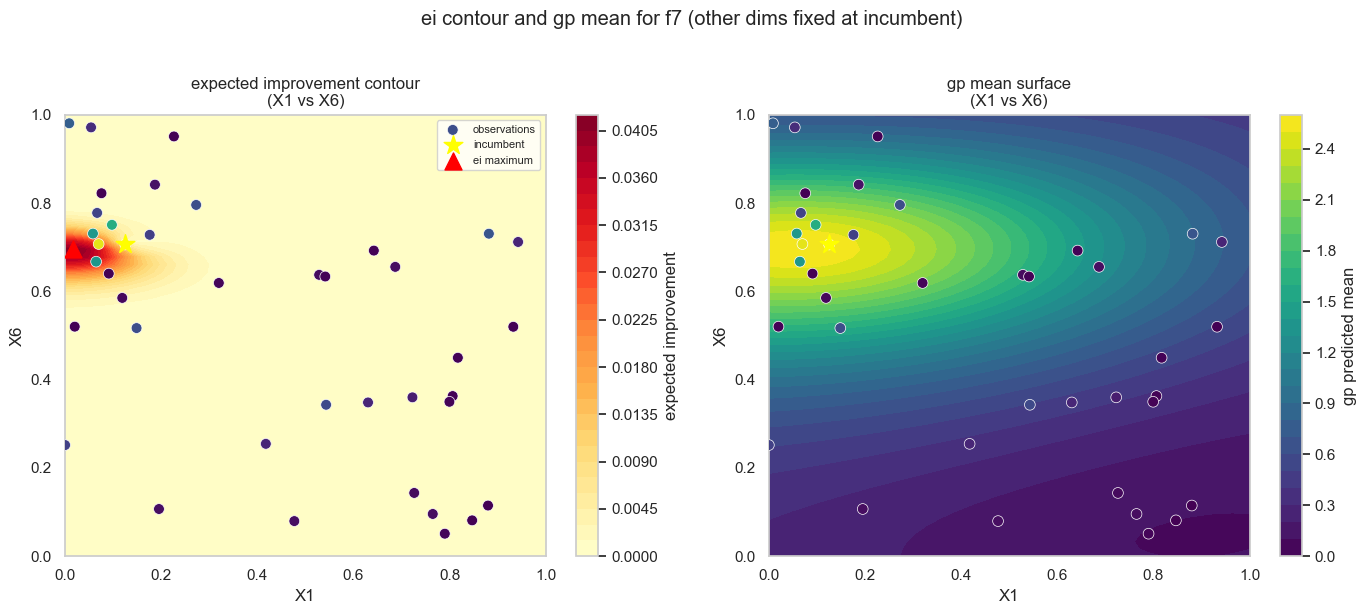


expected improvement contour for f7
incumbent: idx=39, y=2.5580
sweeping X1 (dim 0) vs X5 (dim 4)
all other dimensions fixed at incumbent values

maximum ei at: X1=0.0000, X5=0.3390
ei value at maximum: 0.037361
gp mean at ei maximum: 2.5506


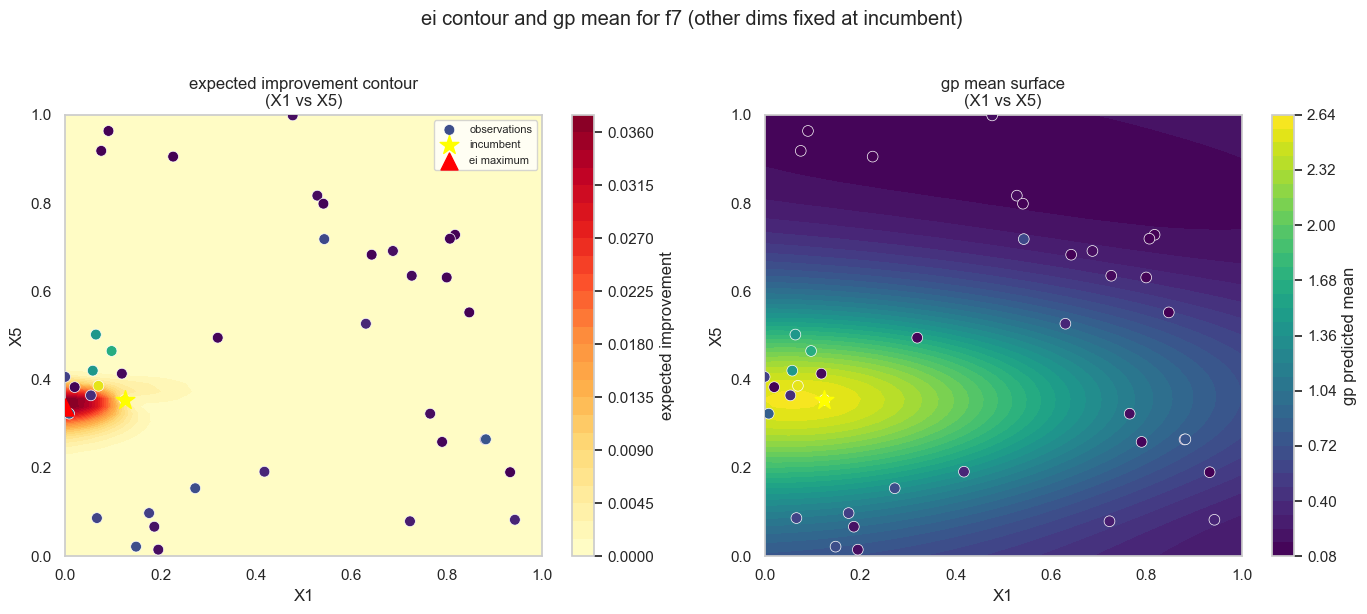

In [89]:
# method: expected improvement contour along top-2 sir dims
# source: fams081076296.pdf (nubo paper), which recommends ei surface
# visualisation for low-budget expensive function optimisation
# fixes all dimensions at incumbent values, sweeps top-2 sir dims
# produces a 2d heatmap showing where ei is highest near the peak
# directly answers: should x1 go lower, should x6 go higher

def ei_contour_plot(df, feature_cols, target_col,
                    dim1=0, dim2=5,
                    gp_fitted=None, n_grid=60):
    """
    plots the expected improvement contour along two selected dimensions.
    all other dimensions are fixed at the incumbent (current best) values.
    uses the already-fitted gp from variance decomposition if provided,
    otherwise fits a new one.

    parameters
    ----------
    df : dataframe containing features and target
    feature_cols : list of input column names
    target_col : output column name
    dim1 : index of first dimension to sweep (default 0 = x1)
    dim2 : index of second dimension to sweep (default 5 = x6)
    gp_fitted : already fitted gp (reuse to avoid refitting)
    n_grid : number of grid points per dimension (default 60)
    """

    from scipy.stats import norm as scipy_norm

    X = df[feature_cols].values
    y = df[target_col].values
    d = X.shape[1]

    # use fitted gp if provided, otherwise fit a new one
    if gp_fitted is None:
        kernel = C(1.0, (1e-2, 1e2)) * Matern(
            length_scale=np.ones(d),
            length_scale_bounds=[(0.05, 5.0)] * d,
            nu=2.5
        ) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.1))
        gp = GPR(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
        gp.fit(X, y)
    else:
        gp = gp_fitted

    # incumbent: current best observed point
    incumbent_idx = np.argmax(y)
    incumbent = X[incumbent_idx].copy()
    y_best = y[incumbent_idx]

    print(f"\nexpected improvement contour for f7")
    print(f"incumbent: idx={incumbent_idx}, y={y_best:.4f}")
    print(f"sweeping {feature_cols[dim1]} (dim {dim1}) vs "
          f"{feature_cols[dim2]} (dim {dim2})")
    print(f"all other dimensions fixed at incumbent values")

    # create 2d grid over the two selected dimensions
    grid1 = np.linspace(0.0, 1.0, n_grid)
    grid2 = np.linspace(0.0, 1.0, n_grid)
    g1, g2 = np.meshgrid(grid1, grid2)

    # build candidate matrix: all other dims fixed at incumbent
    n_points = n_grid * n_grid
    X_grid = np.tile(incumbent, (n_points, 1))
    X_grid[:, dim1] = g1.ravel()
    X_grid[:, dim2] = g2.ravel()

    # gp posterior mean and std at grid points
    mu_grid, sigma_grid = gp.predict(X_grid, return_std=True)
    sigma_grid = np.maximum(sigma_grid, 1e-8)

    # expected improvement: ei(x) = sigma * [z * phi(z) + phi(z)]
    # where z = (mu - y_best) / sigma
    # this is the standard ei formula for maximisation
    z = (mu_grid - y_best) / sigma_grid
    ei_grid = sigma_grid * (z * scipy_norm.cdf(z) + scipy_norm.pdf(z))
    ei_grid = np.maximum(ei_grid, 0.0)

    ei_map = ei_grid.reshape(n_grid, n_grid)
    mu_map = mu_grid.reshape(n_grid, n_grid)

    # find grid point with maximum ei
    best_grid_idx = np.argmax(ei_grid)
    best_d1 = X_grid[best_grid_idx, dim1]
    best_d2 = X_grid[best_grid_idx, dim2]
    print(f"\nmaximum ei at: {feature_cols[dim1]}={best_d1:.4f}, "
          f"{feature_cols[dim2]}={best_d2:.4f}")
    print(f"ei value at maximum: {ei_grid[best_grid_idx]:.6f}")
    print(f"gp mean at ei maximum: {mu_grid[best_grid_idx]:.4f}")

    # plot ei contour and gp mean contour side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ei contour
    cf1 = axes[0].contourf(g1, g2, ei_map, levels=30, cmap="YlOrRd")
    plt.colorbar(cf1, ax=axes[0], label="expected improvement")
    axes[0].scatter(
        X[:, dim1], X[:, dim2],
        c=y, cmap="viridis", s=60, edgecolors="white", linewidths=0.5,
        zorder=5, label="observations"
    )
    axes[0].scatter(
        incumbent[dim1], incumbent[dim2],
        c="yellow", s=200, marker="*", zorder=6, label="incumbent"
    )
    axes[0].scatter(
        best_d1, best_d2,
        c="red", s=150, marker="^", zorder=6, label="ei maximum"
    )
    axes[0].set_xlabel(feature_cols[dim1])
    axes[0].set_ylabel(feature_cols[dim2])
    axes[0].set_title(f"expected improvement contour\n"
                      f"({feature_cols[dim1]} vs {feature_cols[dim2]})")
    axes[0].legend(fontsize=8)

    # gp mean contour
    cf2 = axes[1].contourf(g1, g2, mu_map, levels=30, cmap="viridis")
    plt.colorbar(cf2, ax=axes[1], label="gp predicted mean")
    axes[1].scatter(
        X[:, dim1], X[:, dim2],
        c=y, cmap="viridis", s=60, edgecolors="white", linewidths=0.5,
        zorder=5
    )
    axes[1].scatter(
        incumbent[dim1], incumbent[dim2],
        c="yellow", s=200, marker="*", zorder=6
    )
    axes[1].set_xlabel(feature_cols[dim1])
    axes[1].set_ylabel(feature_cols[dim2])
    axes[1].set_title(f"gp mean surface\n"
                      f"({feature_cols[dim1]} vs {feature_cols[dim2]})")

    plt.suptitle("ei contour and gp mean for f7 (other dims fixed at incumbent)",
                 y=1.02)
    plt.tight_layout()
    plt.show()

    return ei_grid, mu_grid, best_d1, best_d2


# run for the two highest sir loading dimensions: x1 (dim 0) and x6 (dim 5)
ei_f7, mu_f7, ei_best_x1, ei_best_x6 = ei_contour_plot(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1",
    dim1=0,   # x1: strongest sir loading
    dim2=5,   # x6: second strongest sir loading
    gp_fitted=gp_f7  # reuse the gp fitted in variance decomposition
)

# also run for x1 vs x5 to check the second most active dimension pair
ei_f7_x1x5, mu_f7_x1x5, ei_best_x1b, ei_best_x5 = ei_contour_plot(
    df_f7,
    feature_cols=["X1", "X2", "X3", "X4", "X5", "X6"],
    target_col="y1",
    dim1=0,   # x1
    dim2=4,   # x5: third strongest sir loading
    gp_fitted=gp_f7
)

#### f7 | Tightened Trust Region Ensemble Exploitation with SIR-Updated Directional Scoring

In [90]:
import numpy as np
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor as KNN
from sklearn.model_selection import KFold
from xgboost import XGBRegressor as XGB

In [91]:
# Separate inputs (X) and outputs (y)
X_train_7 = df_f7[[c for c in df_f7.columns if c.startswith("X")]].values
y_train_7 = df_f7["y1"].values
print(X_train_7)
print(y_train_7)

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [92]:
def propose_f7_query(X_train_7, y_train_7):
    """
    week 11 strategy for f7: tightened trust region ensemble exploitation.

    research basis: eriksson et al. (2019), turbo, neurips 2019.
    competition: neurips 2020 bbo challenge, optuna team (ozaki et al., 5th place).

    week 10 found a new global best: y=2.558 at [0.125, 0.293, 0.563, 0.153, 0.354, 0.706].
    the trust region is now re-centred on the new incumbent per the turbo success rule.
    the sir direction has updated substantially with the new observation:
      x1: -0.588, x5: -0.462, x6: +0.532, x4: -0.350, x3: +0.181
    bootstrap stability improved from 79.5 to 53.1 degrees, making the direction
    more reliable. the isomap confirms all high-value points cluster at -0.75.

    key changes from week 10:
      1. trust region re-centred on new best (row 39) with width contracted to 0.15
      2. top-5 used for cluster centroid (includes row 39)
      3. sir directional boost updated: x3 no longer penalised, x4 now included
      4. k-means cluster 2 centroid used as secondary validation anchor
      5. distance guard tightened to 0.03 to allow denser coverage of small region
    """

    n_dims = X_train_7.shape[1]  # 6 for f7

    # step 1: identify top-5 observations
    # top-5 now includes the new best (row 39, y=2.558)
    # using top-5 instead of top-4 incorporates the new structural information
    # while keeping the cluster definition stable
    top_k = 5
    top_indices = np.argsort(y_train_7)[-top_k:]
    top_X = X_train_7[top_indices]
    top_y = y_train_7[top_indices]

    print(f"top-{top_k} observations defining trust region:")
    for i, idx in enumerate(top_indices):
        print(f"  idx={idx}: X={X_train_7[idx].round(3)}, y={y_train_7[idx]:.4f}")

    # the new best (row 39) gets double weight in the centroid calculation
    # this implements the turbo re-centring rule: weight the incumbent more heavily
    # to ensure the trust region is centred near the confirmed peak
    incumbent_idx = np.argmax(y_train_7)
    incumbent_X = X_train_7[incumbent_idx]
    print(f"incumbent (new best): idx={incumbent_idx}, X={incumbent_X.round(4)}")

    # weighted centroid: incumbent contributes 2x, others 1x
    weights_centroid = np.ones(top_k)
    incumbent_position = np.where(top_indices == incumbent_idx)[0]
    if len(incumbent_position) > 0:
        weights_centroid[incumbent_position[0]] = 2.0
    weights_centroid /= weights_centroid.sum()

    cluster_centroid = (top_X * weights_centroid[:, None]).sum(axis=0)
    print(f"weighted cluster centroid: {cluster_centroid.round(4)}")

    # k-means cluster 2 centroid from week 11 eda as secondary reference
    # cluster 2 centroid: x1=0.086, x2=0.545, x3=0.421, x4=0.318, x5=0.336, x6=0.760
    kmeans_cluster2_centroid = np.array([0.086, 0.545, 0.421, 0.318, 0.336, 0.760])
    print(f"k-means cluster 2 centroid: {kmeans_cluster2_centroid.round(4)}")

    # --- step 2: define tightened trust region ---
    # width contracted from 0.20 to 0.15 per the turbo success rule:
    # after a successful improvement, contract the trust region to focus search
    # near the confirmed peak rather than the broader neighbourhood
    tr_width = 0.15

    tr_lower = np.clip(cluster_centroid - tr_width / 2.0, 0.0, 1.0)
    tr_upper = np.clip(cluster_centroid + tr_width / 2.0, 0.0, 1.0)

    # expand any dimension where the top-5 empirical range exceeds the trust region
    # this ensures all top-5 points are covered (with small margin)
    for dim in range(n_dims):
        empirical_min = top_X[:, dim].min() - 0.03
        empirical_max = top_X[:, dim].max() + 0.03
        if empirical_min < tr_lower[dim]:
            tr_lower[dim] = max(0.0, empirical_min)
        if empirical_max > tr_upper[dim]:
            tr_upper[dim] = min(1.0, empirical_max)

    print(f"trust region lower: {tr_lower.round(4)}")
    print(f"trust region upper: {tr_upper.round(4)}")
    print(f"trust region volume: {np.prod(tr_upper - tr_lower):.6f}")

    # step 3: generate sobol candidates within trust region 
    # 4096 candidates in a smaller region gives higher density than week 10
    # density increase compensates for the contracted trust region width
    sampler = Sobol(d=n_dims, scramble=True, seed=11)
    unit_candidates = sampler.random_base2(m=12)  # 4096 points in [0,1]^6

    # scale from unit cube to trust region bounds
    candidates = tr_lower + unit_candidates * (tr_upper - tr_lower)
    print(f"generated {len(candidates)} sobol candidates within trust region")

    # step 4: distance guard
    # threshold reduced to 0.03 (from 0.04 in week 10) to allow denser coverage
    # the trust region is smaller, so a smaller guard is appropriate
    dist_threshold = 0.03
    dists = np.array([
        np.min(np.linalg.norm(X_train_7 - c, axis=1))
        for c in candidates
    ])
    candidates = candidates[dists >= dist_threshold]
    print(f"candidates after distance guard (threshold={dist_threshold}): {len(candidates)}")

    if len(candidates) < 30:
        # if very few candidates survive, relax to 0.015
        all_candidates = tr_lower + unit_candidates * (tr_upper - tr_lower)
        dists_all = np.array([
            np.min(np.linalg.norm(X_train_7 - c, axis=1))
            for c in all_candidates
        ])
        candidates = all_candidates[dists_all >= 0.015]
        print(f"distance guard relaxed: {len(candidates)} candidates")

    # step 5: four-model ensemble (week 6 and week 10 validated architecture) 
    # gp: smooth global structure within the small trust region
    # svr: local curvature, highest cv weight in weeks 6 and 10
    # knn: sharp local peak, non-parametric, no stationarity assumptions
    # xgb: non-linear interaction terms, lower weight but adds diversity
    kernel = C(1.0, (1e-2, 1e2)) * Matern(
        length_scale=np.ones(n_dims),
        length_scale_bounds=[(1e-2, 1e2)] * n_dims,
        nu=2.5,
    )
    gp = GPR(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
    svr = SVR(C=5.0, epsilon=0.1, kernel="rbf")
    knn = KNN(n_neighbors=4, weights="distance")
    xgb = XGB(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        verbosity=0,
    )
    models = [gp, svr, knn, xgb]
    model_names = ["gp", "svr", "knn", "xgb"]

    # step 6: 5-fold cv weighting 
    # identical to weeks 6 and 10, validated as stable
    # svr has consistently received the highest weight
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_errors = []

    for model in models:
        fold_errors = []
        for train_idx, test_idx in kf.split(X_train_7):
            X_tr, X_te = X_train_7[train_idx], X_train_7[test_idx]
            y_tr, y_te = y_train_7[train_idx], y_train_7[test_idx]
            model.fit(X_tr, y_tr)
            preds = model.predict(X_te)
            fold_errors.append(np.mean((preds - y_te) ** 2))
        cv_errors.append(np.mean(fold_errors))

    cv_errors = np.array(cv_errors)
    inv_errors = 1.0 / (cv_errors + 1e-8)
    ens_weights = inv_errors / np.sum(inv_errors)

    print(f"cv errors:        {dict(zip(model_names, cv_errors.round(4)))}")
    print(f"ensemble weights: {dict(zip(model_names, ens_weights.round(4)))}")

    # step 7: fit all models on full training data 
    for model in models:
        model.fit(X_train_7, y_train_7)

    # step 8: ensemble mean and variance at candidates 
    preds = np.column_stack([m.predict(candidates) for m in models])
    mean_ens = preds.dot(ens_weights)

    # 3x variance inflation: validated in weeks 4, 6, and 10
    var_ens = np.var(preds, axis=1)
    var_inflated = 3.0 * var_ens

    # acquisition: validated week 6 and 10 formula
    acq_values = mean_ens + 1.5 * var_inflated

    # step 9: sir-updated directional boost 
    # updated sir direction (week 11 eda, bootstrap stability 53 degrees):
    #   x1: -0.588 (stronger negative loading than before)
    #   x5: -0.462 (strong negative)
    #   x6: +0.532 (strong positive)
    #   x4: -0.350 (moderate negative, now more prominent)
    #   x3: +0.181 (weak positive, no longer dominant)
    #
    # the sir plot (image 1) shows a monotonically increasing relationship
    # with the sir score -- higher sir score corresponds to higher y
    # sir score = x * sir_direction, so we reward candidates with high sir score
    # this is equivalent to rewarding: low x1, low x5, high x6, low x4

    sir_direction = np.array([-0.5876, -0.0582, 0.1807, -0.3498, -0.4615, 0.5324])
    sir_scores = candidates.dot(sir_direction)

    # normalise sir scores to [0.85, 1.15] to use as a soft multiplicative boost
    # range is narrower than week 10 (was [0.8, 1.2]) because the trust region
    # is already concentrated in the high-sir-score region
    sir_min, sir_max = sir_scores.min(), sir_scores.max()
    if sir_max > sir_min:
        sir_weight = 0.85 + 0.30 * (sir_scores - sir_min) / (sir_max - sir_min)
    else:
        sir_weight = np.ones(len(candidates))

    # final weighted acquisition
    acq_weighted = acq_values * sir_weight

    # step 10: select best candidate 
    best_idx = np.argmax(acq_weighted)
    next_x = candidates[best_idx]

    # ensemble prediction at selected point
    next_preds = np.array([m.predict(next_x.reshape(1, -1))[0] for m in models])
    predicted_y = float(next_preds.dot(ens_weights))

    # step 11: diagnostics 
    min_dist = float(np.min(np.linalg.norm(X_train_7 - next_x, axis=1)))
    sir_at_selected = float(next_x.dot(sir_direction))
    incumbent_sir = float(incumbent_X.dot(sir_direction))

    print(f"\nweek 11 f7 selection")
    print(f"selected point:        {next_x}")
    print(f"predicted y (ens):     {predicted_y:.6f}")
    print(f"acq score:             {acq_weighted[best_idx]:.6f}")
    print(f"sir score at selected: {sir_at_selected:.4f} (incumbent: {incumbent_sir:.4f})")
    print(f"x1: {next_x[0]:.4f}  (incumbent: {incumbent_X[0]:.4f}, sir loading: -0.588)")
    print(f"x2: {next_x[1]:.4f}  (incumbent: {incumbent_X[1]:.4f}, sir loading: -0.058)")
    print(f"x3: {next_x[2]:.4f}  (incumbent: {incumbent_X[2]:.4f}, sir loading: +0.181)")
    print(f"x4: {next_x[3]:.4f}  (incumbent: {incumbent_X[3]:.4f}, sir loading: -0.350)")
    print(f"x5: {next_x[4]:.4f}  (incumbent: {incumbent_X[4]:.4f}, sir loading: -0.462)")
    print(f"x6: {next_x[5]:.4f}  (incumbent: {incumbent_X[5]:.4f}, sir loading: +0.532)")
    print(f"min dist to training:  {min_dist:.4f}")
    print(f"current best y:        {y_train_7.max():.6f}")

    # sanity checks
    assert min_dist >= 0.02, f"distance guard violated: {min_dist:.4f}"
    assert np.all(next_x >= tr_lower - 0.01), "lower bound violated"
    assert np.all(next_x <= tr_upper + 0.01), "upper bound violated"

    return next_x, predicted_y, ens_weights


next_x, predicted_y, ens_weights = propose_f7_query(X_train_7, y_train_7)

top-5 observations defining trust region:
  idx=36: X=[0.064 0.413 0.67  0.193 0.502 0.667], y=1.3516
  idx=6: X=[0.058 0.492 0.247 0.218 0.42  0.731], y=1.3650
  idx=33: X=[0.097 0.335 0.37  0.382 0.465 0.751], y=1.5985
  idx=35: X=[0.07  0.32  0.577 0.211 0.386 0.707], y=2.4483
  idx=39: X=[0.125 0.293 0.563 0.153 0.354 0.706], y=2.5580
incumbent (new best): idx=39, X=[0.1253 0.2927 0.5633 0.1531 0.3543 0.7063]
weighted cluster centroid: [0.09   0.3574 0.4985 0.2184 0.4137 0.7115]
k-means cluster 2 centroid: [0.086 0.545 0.421 0.318 0.336 0.76 ]
trust region lower: [0.015  0.2627 0.2174 0.1231 0.3243 0.6365]
trust region upper: [0.165  0.5217 0.6995 0.4124 0.5322 0.7865]
trust region volume: 0.000169
generated 4096 sobol candidates within trust region
candidates after distance guard (threshold=0.03): 4096
cv errors:        {'gp': 0.0918, 'svr': 0.1506, 'knn': 0.1687, 'xgb': 0.2274}
ensemble weights: {'gp': 0.3911, 'svr': 0.2383, 'knn': 0.2128, 'xgb': 0.1579}

week 11 f7 selection
sel

In [ ]:
# week 11 f7 selection from other notebook

# selected point:
# [0.0448, 0.3015, 0.6105, 0.2519, 0.3515, 0.6975]

# predicted y (ensemble):
# 1.99275

# acquisition score:
# 3.109

# sir score at selected:
# 0.1874
# incumbent sir score:
# 0.1701

# feature comparison vs incumbent and sir loadings

# x1: 0.0448
# incumbent: 0.1253
# sir loading: -0.588

# x2: 0.3015
# incumbent: 0.2927
# sir loading: -0.058

# x3: 0.6105
# incumbent: 0.5633
# sir loading: +0.181

# x4: 0.2519
# incumbent: 0.1531
# sir loading: -0.350

# x5: 0.3515
# incumbent: 0.3543
# sir loading: -0.462

# x6: 0.6975
# incumbent: 0.7063
# sir loading: +0.532

# minimum distance to training data:
# 0.0708

# current best y:
# 2.557966